# AI Vision Lab — Image Classification

## Objective

Build an image-classification pipeline in PyTorch and compare:

1. A CNN trained from scratch
2. A pretrained ResNet18 using transfer learning

The experiment will investigate whether transfer learning improves
classification performance compared with a small CNN trained from scratch.

## Dataset

CIFAR-10

## Main concepts

- Image tensors
- RGB channels
- Convolutional layers
- Activation functions
- Pooling
- Fully connected layers
- CNN training
- Evaluation
- Pretrained models
- Transfer learning
- ResNet

In [70]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [71]:
transform = transforms.ToTensor()


In [72]:
import os

data_path = "/Users/srisuphachawla/Documents/Mini_Projects/AI-Vision-Lab-PyTorch/data/cifar-10-batches-py"

print(os.listdir(data_path))

['data_batch_1', 'readme.html', 'batches.meta', 'data_batch_2', 'data_batch_5', 'test_batch', 'data_batch_4', 'data_batch_3']


In [73]:
train_dataset = torchvision.datasets.CIFAR10(
    root="/Users/srisuphachawla/Documents/Mini_Projects/AI-Vision-Lab-PyTorch/data",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="/Users/srisuphachawla/Documents/Mini_Projects/AI-Vision-Lab-PyTorch/data",
    train=False,
    download=False,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Test images:", len(test_dataset))

Training images: 50000
Test images: 10000


In [74]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [75]:
image, label = train_dataset[0]

print(image.shape) # [channels, height, width]
print(label)

torch.Size([3, 32, 32])
6


In [76]:
classes = train_dataset.classes
print(classes)
print(len(classes))
print(len(train_dataset))
print(len(test_dataset))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10
50000
10000


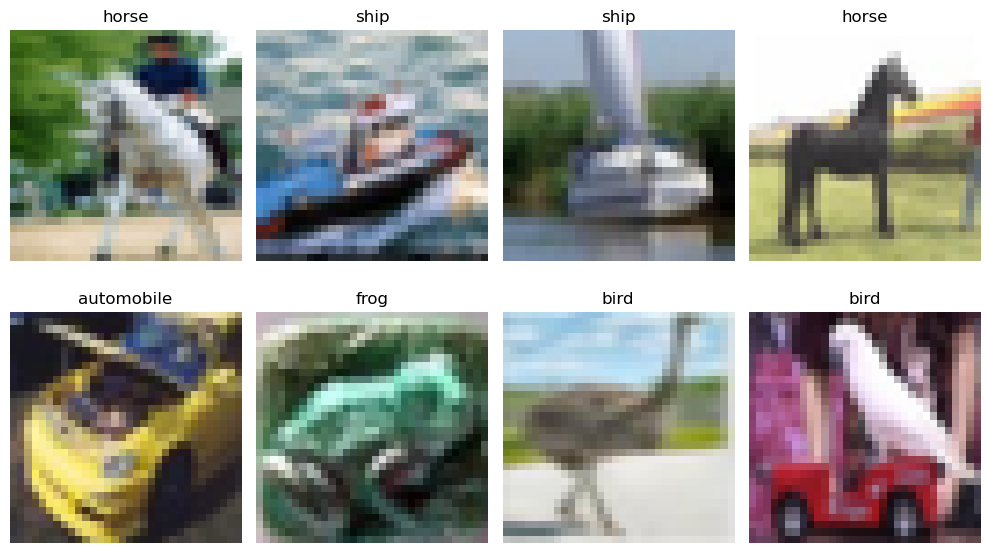

In [77]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [78]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding =1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 8 * 8, 10) # 10 outputs

    def forward(self, x):
        x = self.conv_block(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = CNNClassifier()
print(model)

CNNClassifier(
  (conv_block): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=8192, out_features=10, bias=True)
)


In [79]:
# loss and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [80]:
# inspecting one batch

images, labels = next(iter(train_loader))

print(images.shape) # [ batchsize, RGB, height, width ]
print(labels.shape)


torch.Size([64, 3, 32, 32])
torch.Size([64])


In [81]:
# one batch of images
images, labels = next(iter(train_loader))

# Send the images through the CNN - frwd pass
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print(outputs[0]) # logits


Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])
tensor([-0.0292,  0.0467,  0.0115,  0.0241,  0.0740, -0.0324, -0.0087,  0.0112,
         0.0724, -0.0600], grad_fn=<SelectBackward0>)


In [83]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        outputs = model(images) # forward pass 
        loss = criterion(outputs, labels) # calc loss

        # backpropagation
        optimizer.zero_grad()
        loss.backward()

        # update weights
        optimizer.step()

        # keep track of total loss
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 0.9881
Epoch [2/5], Loss: 0.8291
Epoch [3/5], Loss: 0.7340
Epoch [4/5], Loss: 0.6573
Epoch [5/5], Loss: 0.5932


### Evaluating the CNN

In [86]:
def evaluate_model(model, test_loader, classes):
    model.eval()
    
    correct = 0
    total = 0

    class_correct = [0] * len(classes)
    class_total = [0] * len(classes)
    
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for label, prediction in zip(labels, predicted):
                class_total[label] += 1

                if label == prediction:
                    class_correct[label] += 1

    overall_accuracy = 100 * correct / total
    class_accuracies = {}

    for i, class_name in enumerate(classes):
        class_accuracies[class_name] = (100* class_correct[i] / class_total[i])

    return overall_accuracy, class_accuracies

In [87]:
# Per Class Accuracy

classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

test_accuracy, class_accuracies = evaluate_model(model, test_loader, classes)

print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nPer-Class Accuracy:")

for class_name, accuracy in class_accuracies.items():
    print(f"{class_name:12s}: {accuracy:.2f}%")

Test Accuracy: 71.82%

Per-Class Accuracy:
airplane    : 75.50%
automobile  : 85.40%
bird        : 41.80%
cat         : 54.20%
deer        : 55.50%
dog         : 75.10%
frog        : 82.70%
horse       : 81.90%
ship        : 82.60%
truck       : 83.50%


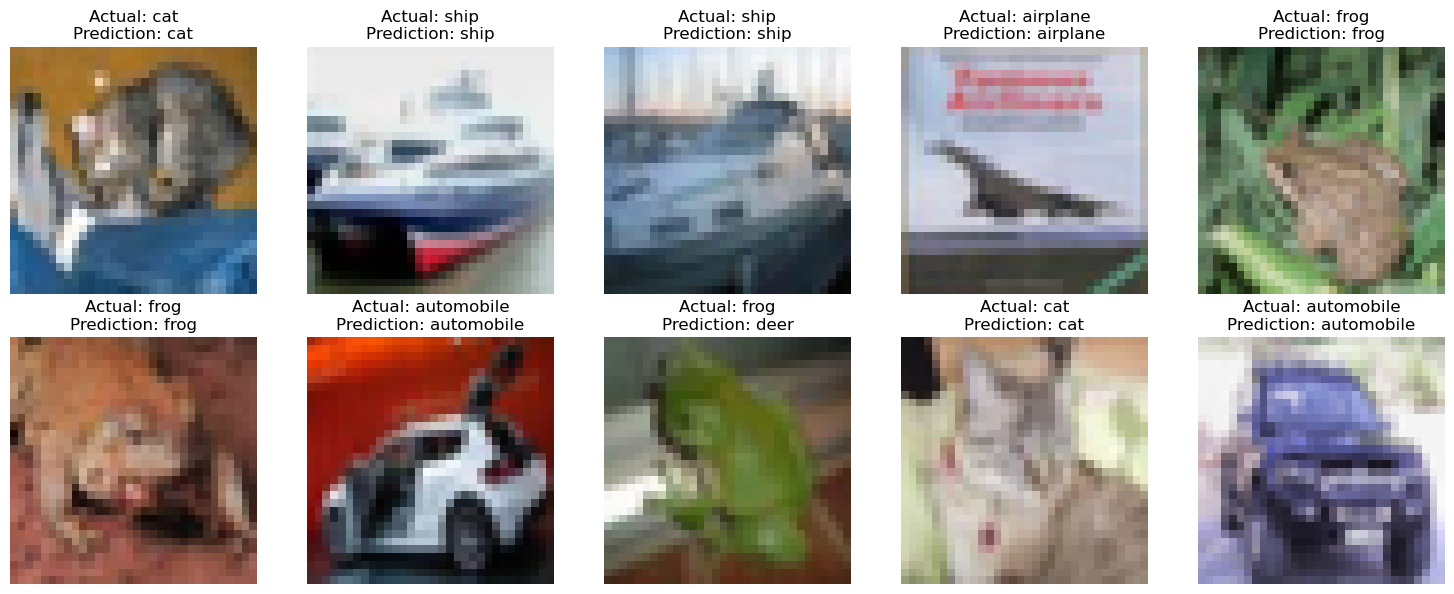

In [96]:
# checking what kind of mistakes the model is making

def show_predictions(model, test_loader, classes, num_images=10):
    model.eval()

    images, labels = next(iter(test_loader))
    with torch.no_grad():

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    plt.figure(figsize=(15, 6))

    for i in range(num_images):
        plt.subplot(2, 5, i+1)

        image = images[i].permute(1, 2, 0)
        plt.imshow(image)

        actual = classes[labels[i]]
        prediction = classes[predicted[i]]

        plt.title(
            f"Actual: {actual}\n"
            f"Prediction: {prediction}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(model, test_loader, classes, num_images=10)

## Question: Can we start with a pre-trained neural network and adapt it to CIFAR-10?  

### Transfer Learning

In [ ]:
# load pretraiened ResNet 18
# Idea: Pretrained Resnet -> adapt to our task -> CIFAR10 classification
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights = weights)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

RenNet18 was designed for ImageNet classification, which has 1000 classes. We have only 10 classes, therefore, we replace the final layer

In [101]:
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

print(num_features)
print(resnet.fc)

512
Linear(in_features=512, out_features=10, bias=True)
